In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame[["mean radius","mean smoothness", "target"]]

In [60]:
df.sample(5)

,mean radius,mean smoothness,target
388,11.27,0.08365,1
375,16.17,0.09880,1
78,20.18,0.12860,0
316,12.18,0.07734,1
333,11.25,0.08306,1


In [61]:
# loading all  neccesary tensorflow librarires
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


<Axes: xlabel='mean radius', ylabel='mean smoothness'>

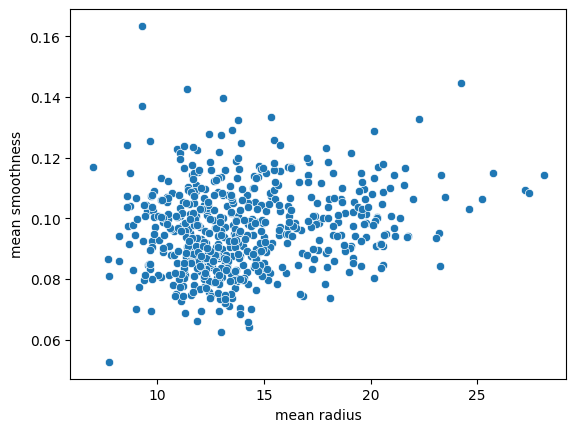

In [62]:
sns.scatterplot(x = df.iloc[:,0] , y =  df.iloc[:,1])

In [63]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

training the model without normalization


In [65]:
model = Sequential()

model.add(Dense(32, activation = "relu", input_dim = 2))

model.add(Dense(1, activation = "sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129 (516.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(optimizer = "sgd" , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [68]:
history = model.fit(X_train, y_train, epochs = 250, validation_split = 0.2)

Epoch 1/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4780 - loss: 0.7694 - val_accuracy: 0.3626 - val_loss: 0.7858
Epoch 2/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5165 - loss: 0.7130 - val_accuracy: 0.6374 - val_loss: 0.7054
Epoch 3/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5632 - loss: 0.6997 - val_accuracy: 0.6374 - val_loss: 0.7267
Epoch 4/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5137 - loss: 0.7456 - val_accuracy: 0.3626 - val_loss: 0.7166
Epoch 5/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5879 - loss: 0.6904 - val_accuracy: 0.6374 - val_loss: 0.6842
Epoch 6/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5440 - loss: 0.6945 - val_accuracy: 0.6374 - val_loss: 0.6786
Epoch 7/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5934 - loss: 0.7266 - val_accuracy: 0.6374 - val_loss: 0.6802
Epoch 8/250
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5714 - loss: 0.6793 - val_accuracy: 0.6374 -

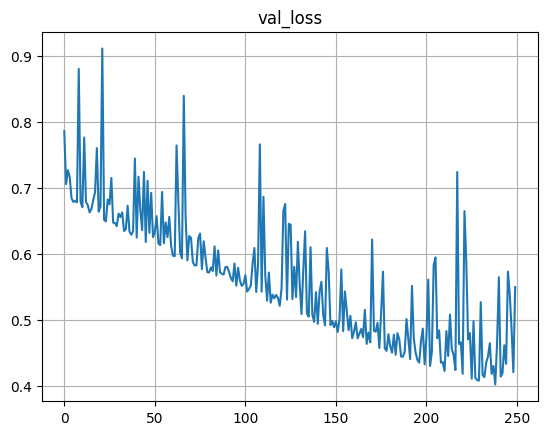

In [69]:

plt.plot(history.history['val_loss'])
plt.title('val_loss')
plt.grid()
plt.show()



we can clearly see that even after 250 epochs the loss never converges , now lets trying doing it with scaled data

In [70]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

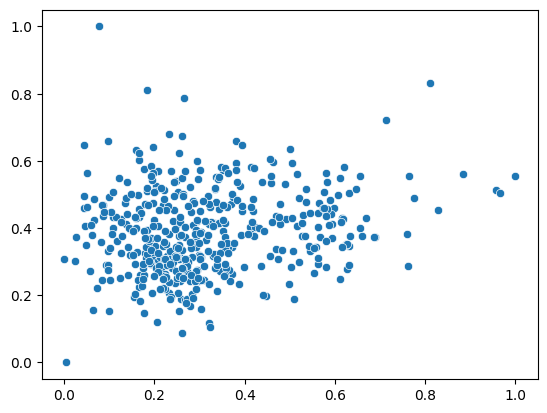

In [80]:
sns.scatterplot(x = X_train_scaled[:,0] , y =  X_train_scaled[:,1])

In [75]:
model = Sequential()

model.add(Dense(32, activation = "relu", input_dim = 2))

model.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.compile(optimizer = "sgd" , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [77]:
history = model.fit(X_train_scaled, y_train, epochs = 250, validation_split = 0.2 , verbose = 0 )

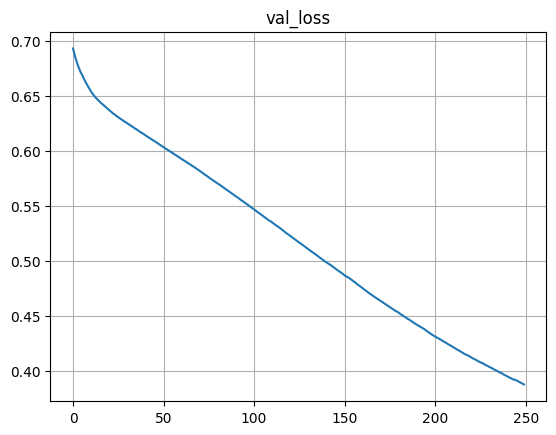

In [78]:
plt.plot(history.history['val_loss'])
plt.title('val_loss')
plt.grid()
plt.show()

# as we can see after scaling it converges very smoothly ,